In [1]:
import warnings
warnings.filterwarnings(action='ignore')
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_finance import candlestick_ohlc

from AnalysisTools.DBManager import MarketDB
from AnalysisTools.Strategy import Strategy

/root/miniconda3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [3]:
# Prepare samples
cushion_date = "2015-01-01"
start_date= "2016-01-01"
end_date = "2021-02-15"

etf = "KODEX 반도체"
sample = MarketDB("ETF").get_daily_price(etf, cushion_date, end_date)

In [4]:
sample['rtn'] = sample['close'].pct_change()
sample['acc_rtn'] = (1.0 + sample['rtn']).cumprod()

In [5]:
book = sample[['open', 'high', 'low', 'close']].copy()
book['noise'] = 1 - abs((book.open - book.close)/(book.high - book.low))
book['noise'] = book['noise'].rolling(window=20).mean()
book['high_2day'] = book['high'].rolling(window=2).max()
book['low_2day'] = book['low'].rolling(window=2).min()
for date in book.index:
    entry_point = book.loc[date, 'open']
    #breakout = 0.5*(book.shift(1).loc[date, 'high'] - book.shift(1).loc[date, 'low'])
    #breakout = book.shift(1).loc[date, 'noise']*(book.shift(1).loc[date, 'high'] - book.shift(1).loc[date, 'low'])
    #breakout = min(book.shift(1).loc[date, 'noise'], 0.5)*(book.shift(1).loc[date, 'high'] - book.shift(1).loc[date, 'low'])
    breakout = max(book.shift(1).loc[date, 'noise'], 0.6)*(book.shift(1).loc[date, 'high'] - book.shift(1).loc[date, 'low'])
    #breakout = book.shift(1).loc[date, 'noise']*(book.shift(1).loc[date, 'high_2day'] - book.shift(1).loc[date, 'low_2day'])

    book.loc[date, 'target'] = entry_point + breakout

start_date = datetime.strptime(start_date, "%Y-%m-%d").date()
end_date = datetime.strptime(end_date, "%Y-%m-%d").date()
sample = sample[start_date:]
book = book[start_date:]

sample = sample.dropna()
book = book.dropna()

In [6]:
def evaluate(sample):
    CAGR = sample['acc_rtn'][-1] ** (252.0/len(sample.index)) - 1.0
    
    historical_max = sample['acc_rtn'].cummax()
    daily_drawdown = sample['acc_rtn'] / historical_max - 1.0
    historical_dd = daily_drawdown.cummin()
    MDD = historical_dd.min()

    VOL = np.std(sample['rtn'])*np.sqrt(len(sample.index))

    Sharpe = np.mean(sample['rtn']) / np.std(sample['rtn']) * np.sqrt(len(sample.index))

    print(f"CAGR: {round(CAGR*100, 2)}%")
    print(f"MDD: {round(MDD*100, 2)}%")
    print(f"VOL: {round(VOL*100, 2)}%")
    print(f"Sharpe: {round(Sharpe, 2)}")

In [7]:
# trade
book['trade'] = ''
book['rtn'] = 0.
commision = 0.005
for date in book.index:
    # sell stocks
    if book.shift(1).loc[date, 'trade'] == 'buy':
        book.loc[date, 'rtn'] = book.loc[date, 'open'] / book.shift(1).loc[date, 'target'] - 1.0 - commision
    # check whether to buy
    if book.loc[date, 'high'] > book.loc[date, 'target']:
        book.loc[date, 'trade'] = 'buy'
book['acc_rtn'] = (book['rtn'] + 1.0).cumprod()

In [9]:
evaluate(sample)
evaluate(book)

CAGR: 14.64%
MDD: -44.51%
VOL: 60.5%
Sharpe: 1.58
CAGR: -2.85%
MDD: -27.98%
VOL: 29.4%
Sharpe: -0.34


<AxesSubplot:xlabel='date'>

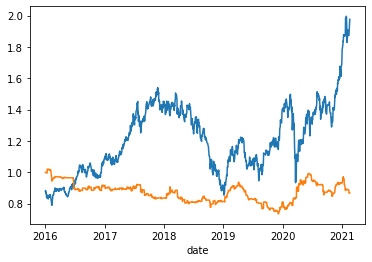

In [10]:
sample.acc_rtn.plot()
book.acc_rtn.plot()
